# **4.4.3 Knapsack Example**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/15ajXRLnvrTFiVAfrQ5If4r_7VthBdQV1?usp=sharing)

The manager of an Operations Research department in a large company has a list of projects that she would like to initiate. Each project has an expected payback expressed in thousands of dollars as the net present value over a 10-year period. Although all of the projects would be beneficial, there are simply not enough resources, in person days, available this month to do all of them. The estimates of resources and return are:

<br>

<div align="center">

| Project | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Estimated value | 15 | 20 | 5 | 25 | 22 | 17 | 30 | 4 |
| Days | 51 | 60 | 40 | 62 | 63 | 50 | 70 | 10 |

</div>

<br>

There are 250 person-days available this month. Which projects should be selected? At the end of this month, the manager must write a report summarizing the results from completed projects; any projects that are not completed cannot be included among the successful projects in the report.

&nbsp;&nbsp;&nbsp;&nbsp;Define $x_i = 1$ if project $i$ is selected, and 0 otherwise. The “node 0” problem can be modeled as:

$$
\begin{aligned}
\text{maximize} \qquad
& 15x_1 + 20x_2 + 5x_3 + 25x_4 + 22x_5 + 17x_6 + 30x_7 + 4x_8 \\[6pt]
\text{subject to} \qquad
& 51x_1 + 60x_2 + 40x_3 + 62x_4 + 63x_5 + 50x_6 + 70x_7 + 10x_8 \leq 250 \\[6pt]
& x_i = 0 \text{ or } 1
\end{aligned}
$$

&nbsp;&nbsp;&nbsp;&nbsp;When the $0-1$ constraints are relaxed to solve the LP, we replace them with the linear constraints:

$$
0 \leq x_i \leq 1
$$

&nbsp;&nbsp;&nbsp;&nbsp;*Step 0:* $A = \{0\}$, and $z^I = -\infty$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 1:* $A$ is not empty.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 2:* Select node 0 from $A$. ($A$ is now empty).

&nbsp;&nbsp;&nbsp;&nbsp;*Step 3:* $z^* = 96.3$ at the optimal LP solution at point $x^* = (0, 0, 0, 1, 1, 0.9, 1, 1)$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 4:* The solution is feasible.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 5:* $z^* > z^I$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 6:* $x^*$ is not an integer.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 7:* Separate node 0 on a fractional variable. $x_6$ is the only fractional value. Construct node 1, the same problem as node 0 with the additional constraint that $x_6 = 0$. Similarly, construct node 2, the same problem as node 0 with the constraint that $x_6 = 1$. Let $A = \{1, 2\}$.





&nbsp;&nbsp;&nbsp;&nbsp;*Step 1:* $A$ is not empty.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 2:* Select a node from $A$. Suppose we choose node 2; $A = \{1\}$. Add constraint $x_6 = 1$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 3:* $z^* = 96.25$ at the optimal LP solution at point $x^* = (0, 0, 0, 1, 0.92, 1, 1, 1)$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 4:* The solution is feasible.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 5:* $z^* > z^I$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 6:* $x^*$ is not an integer.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 7:* Separate node 2 on a fractional variable. $x_5$ is the only fractional value. Construct node 3, the same problem as node 2 with the additional constraint that $x_5 = 0$. Similarly, construct node 4, the same problem as node 2 with the constraint that $x_5 = 1$. Let $A = \{1, 3, 4\}$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 1:* $A$ is not empty.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 2:* Select a node from $A$. If we choose node 4, then $A = \{1, 3\}$. Add constraint $x_5 = 1$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 3:* $z^* = 96.25$ at the optimal LP solution at point $x^* = (0, 0, 1, 1, 1, 1, 0.5)$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 4:* The solution is feasible.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 5:* $z^* > z^I$.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 6:* $x^*$ is not an integer.



<div align="center">


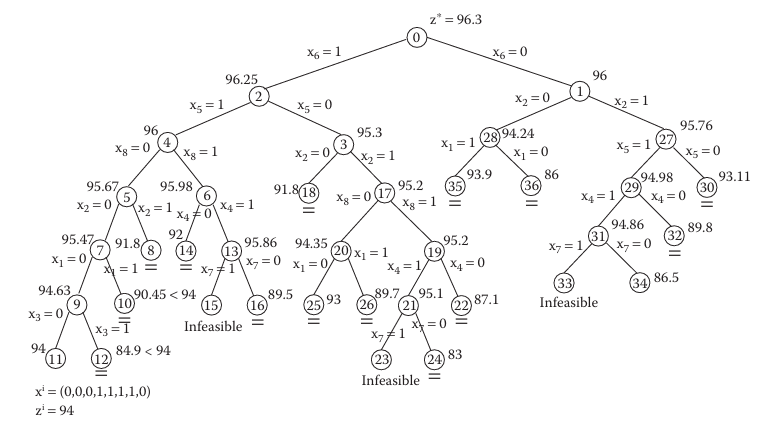





</div>





**Figure 4.4**  
Branch-and-bound tree for the knapsack example.

&nbsp;&nbsp;&nbsp;&nbsp;*Step 7:* Separate node 4 on a fractional variable.$x_8$ is the only fractional value. Construct node 5, the same problem as node 4 with the additional constraint that $x_8 = 0$. Similarly, construct node 6, the same problem as node 4 with the constraint that $x_8 = 1$. Let $A = \{1, 3, 5, 6\}$.

The algorithm continues until the set $A$ is empty. The complete branch-and-bound tree for this problem is illustrated in **Figure 4.4**.



In [1]:
# ========================================
# 4.4.3 Knapsack Example
# LP Relaxation + 0-1 Integer Solution
# ========================================

import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [2]:
# ========================================
# Book Example — Section 4.4.3
# 8 projects, 250 person-days budget
# Textbook answer: projects 4,5,6,7 → value = 94
# ========================================

values  = np.array([15., 20.,  5., 25., 22., 17., 30.,  4.])
weights = np.array([51., 60., 40., 62., 63., 50., 70., 10.])
capacity = 250.
n = len(values)

df = pd.DataFrame({'Project': range(1, n+1),
                   'Value ($K)': values.astype(int),
                   'Days': weights.astype(int)})
print('Book example (Section 4.4.3):')
display(df.set_index('Project').T)
print(f'Budget: {int(capacity)} person-days')


Book example (Section 4.4.3):


Project,1,2,3,4,5,6,7,8
Value ($K),15,20,5,25,22,17,30,4
Days,51,60,40,62,63,50,70,10


Budget: 250 person-days


In [3]:
# ========================================
# Algebraic Method: LP Relaxation (node 0)
# Shows the fractional solution that triggers
# the branch-and-bound process.
# ========================================

# LP relaxation: relax 0-1 to 0 <= x <= 1
bounds_lp = [(0, 1)] * n
res_lp = linprog(-values,
                 A_ub=[weights], b_ub=[capacity],
                 bounds=bounds_lp, method='highs')
z_lp = -res_lp.fun
x_lp = res_lp.x

print('=== LP Relaxation — Node 0 (upper bound) ===')
rows = []
for i in range(n):
    rows.append({'Project': i+1,
                 'x (LP)': round(x_lp[i], 3),
                 'Integer?': chr(10004) if abs(x_lp[i]-round(x_lp[i]))<1e-4 else chr(10008) + ' fractional'})
display(pd.DataFrame(rows).set_index('Project'))
print(f'z* = {z_lp:.2f}  (upper bound — fractional x6 triggers branching)')
print(f'Textbook: z* = 96.3  {chr(10004) if abs(z_lp - 96.3) < 0.1 else chr(10008)}')


=== LP Relaxation — Node 0 (upper bound) ===


,x (LP),Integer?
Project,,
1,0.0,✔
2,0.0,✔
3,0.0,✔
4,1.0,✔
5,1.0,✔
6,0.9,✘ fractional
7,1.0,✔
8,1.0,✔


z* = 96.30  (upper bound — fractional x6 triggers branching)
Textbook: z* = 96.3  ✔


In [4]:
# ========================================
# Ready Function: scipy.optimize.milp
# Solves the 0-1 knapsack directly.
# ========================================

constraints = LinearConstraint([weights], -np.inf, [capacity])
integrality = np.ones(n)              # all binary (0 or 1)
bounds      = Bounds(lb=np.zeros(n), ub=np.ones(n))

res_ip = milp(-values, constraints=constraints,
              integrality=integrality, bounds=bounds)
z_ip   = -res_ip.fun
x_ip   = res_ip.x

print('=== scipy.milp — 0-1 Knapsack Solution ===')
rows = []
total_days = 0
for i in range(n):
    sel = int(round(x_ip[i]))
    if sel: total_days += int(weights[i])
    rows.append({'Project': i+1,
                 'Value': int(values[i]),
                 'Days': int(weights[i]),
                 'Selected': 'YES' if sel else '-'})
display(pd.DataFrame(rows).set_index('Project'))
print(f'Total days used : {total_days} / {int(capacity)}')
print(f'Total value     : {int(round(z_ip))}')
print(f'Textbook answer : 94   {chr(10004) if int(round(z_ip))==94 else chr(10008)}')


=== scipy.milp — 0-1 Knapsack Solution ===


,Value,Days,Selected
Project,,,
1,15,51,-
2,20,60,-
3,5,40,-
4,25,62,YES
5,22,63,YES
6,17,50,YES
7,30,70,YES
8,4,10,-


Total days used : 245 / 250
Total value     : 94
Textbook answer : 94   ✔


In [5]:
# ========================================
# Your Own Knapsack Problem
# Edit values, weights, and capacity, then run.
# ========================================

# Step 1: Define your items
custom_values  = np.array([15., 20.,  5., 25., 22., 17., 30.,  4.])
custom_weights = np.array([51., 60., 40., 62., 63., 50., 70., 10.])
custom_capacity = 250.
item_names = [f'Project {i+1}' for i in range(len(custom_values))]  # optional labels

# Step 2: Solve
cn = len(custom_values)
res = milp(-custom_values,
           constraints=LinearConstraint([custom_weights], -np.inf, [custom_capacity]),
           integrality=np.ones(cn),
           bounds=Bounds(lb=np.zeros(cn), ub=np.ones(cn)))

# Step 3: Print results
print('=== Knapsack Solution ===')
rows, total_w = [], 0
for i in range(cn):
    sel = int(round(res.x[i]))
    if sel: total_w += int(custom_weights[i])
    rows.append({'Item': item_names[i],
                 'Value': int(custom_values[i]),
                 'Weight': int(custom_weights[i]),
                 'Selected': 'YES' if sel else '-'})
display(pd.DataFrame(rows).set_index('Item'))
print(f'Total weight: {total_w} / {int(custom_capacity)}')
print(f'Total value : {int(round(-res.fun))}')


=== Knapsack Solution ===


,Value,Weight,Selected
Item,,,
Project 1,15,51,-
Project 2,20,60,-
Project 3,5,40,-
Project 4,25,62,YES
Project 5,22,63,YES
Project 6,17,50,YES
Project 7,30,70,YES
Project 8,4,10,-


Total weight: 245 / 250
Total value : 94
